# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## My Project:
- https://www.kaggle.com/datasets/khushikyad001/water-pollution-and-disease


This is not a challenge, I am taking this dataset and I am going to predict high and low contamination levels from water characteristics of the dataset
such as chemical composition and physical qualities. This will effectively take a normally regression task and transform it into a binary classification task. I will attempt to do an unsupervised machine learning method/model, but if that does not have great results, then I will switch to an supervised model where I randomly provide some predictive values then try to categorize the other values not given. I may need to adapt the features to be more compatable for this, other than high or low water contamination.

For water contamination level:

- the water contamination threshold will be based on EPA guidelines or WHO guidelines (depending on what contaminants were used for this dataset)
- I will need to see what contaminants are considered, how high of a risk these contaminants have on human health individually, then decide what an appropriate threshold is.

What the data includes:
- Country [categorical]
- Region [categorical]
- Year [numerical]
- Water source type (river, well, tap, lake, spring, pond, etc.) [categorical]
- Contaminant Level (ppm) [numerical continuous]
- pH Level [numerical continuous]
- Turbidity (NTU) [numerical continuous]
- Dissolved Oxygen (mg/L) [numerical continuous]
- Nitrate Level (mg/L) [numerical continuous]
- Lead Concentration (micrograms/L) [numerical continuous]
- Bacteria Count (CFU/mL) [numerical continuous]
- Water Treatment Method [categorical]
- Access to Clean Water (% of Population) [numerical continuous]
- Diarrheal Cases per 100,000 people [numerical continuous]
- Cholera Cases per 100,000 people [numerical continuous]
- Typhoid Cases per 100,000 people [numerical continuous]
- Infant Mortality Rate (per 1,000 live births) [numerical continuous]
- GDP per Capita  (USD) [numerical continuous]
- Healthcare Access Index (0-100) [numerical discrete]
- Urbanization Rate (%) [numerical continuous]
- Sanitation Coverage (% of Population) [numerical continuous]
- Rainfall (mm per year) [numerical continuous]
- Temperature (C) [numerical continuous]
- Population Density (people per km^2) [numerical continuous]

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
#importing necessary packages

import pandas as pd
import numpy as np

In [2]:
#loading the dataset
data = pd.read_csv("water_pollution_disease.csv")

In [3]:
#first view of data
data

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,19.86,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


In [4]:
#checking the shape of the data
data.shape
#3000 rows and 24 columns (features)

(3000, 24)

In [5]:
#checking for missing values
data.isna().any()
#it seems like the row for water treatment method has missing values
#since there is no viable way to impute a value (because it is not continuous), I will see if I can get rid of the rows containing such missing data

Country                                          False
Region                                           False
Year                                             False
Water Source Type                                False
Contaminant Level (ppm)                          False
pH Level                                         False
Turbidity (NTU)                                  False
Dissolved Oxygen (mg/L)                          False
Nitrate Level (mg/L)                             False
Lead Concentration (µg/L)                        False
Bacteria Count (CFU/mL)                          False
Water Treatment Method                            True
Access to Clean Water (% of Population)          False
Diarrheal Cases per 100,000 people               False
Cholera Cases per 100,000 people                 False
Typhoid Cases per 100,000 people                 False
Infant Mortality Rate (per 1,000 live births)    False
GDP per Capita (USD)                             False
Healthcare

In [6]:
data.columns

Index(['Country', 'Region', 'Year', 'Water Source Type',
       'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Water Treatment Method', 'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)'],
      dtype='object')

In [7]:
missing_rows = data[data['Water Treatment Method'].isna()]
missing_rows['Water Treatment Method']
# a total of 747 rows have no available water treatment method --> now the question is if I should not include these rows at all, or if
# I should not consider this feature, but keep all of the rows
# after further investigation, the kaggle page language indicates that all the NaN values are because of no treatment, so I must impute to
# show that there were no efforts to treat these waters

2       NaN
5       NaN
7       NaN
8       NaN
16      NaN
       ... 
2984    NaN
2989    NaN
2991    NaN
2993    NaN
2995    NaN
Name: Water Treatment Method, Length: 747, dtype: object

In [8]:
# I decided to impute all NaN values to none, the original dataset had values = 'None' which automatically converts to NaN, though
# with this data this actually indicates that no water treatment method was used for these samples
data.copy()
data.fillna('none', inplace=True)

In [9]:
# checking to make sure imputation was successful
data['Water Treatment Method']

0       Filtration
1          Boiling
2             none
3          Boiling
4       Filtration
           ...    
2995          none
2996       Boiling
2997       Boiling
2998       Boiling
2999       Boiling
Name: Water Treatment Method, Length: 3000, dtype: object

In [10]:
# creating a new column to replace the contaminant level column (to support classification)
max(data['Contaminant Level (ppm)'])

min(data['Contaminant Level (ppm)'])
# the data ranges from zero to 10 ppm for contamination; I will make the cutoff at 5-10 for high level contamination

high_contamination = data[data['Contaminant Level (ppm)'] >= 1.0]
low_contamination = data[data['Contaminant Level (ppm)'] < 1.0]

In [11]:
high_contamination

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
5,Ethiopia,West,2013,Tap,2.93,8.21,4.03,8.66,31.35,16.74,...,22,55,70.13,84334,53.45,86.11,51.11,2530,8.01,775
7,Mexico,Central,2024,Spring,3.76,6.42,1.35,9.99,2.73,19.44,...,0,10,67.30,76593,7.27,45.22,70.22,940,19.64,111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,Ethiopia,Central,2010,Lake,7.49,6.77,1.76,7.67,9.19,7.10,...,40,79,42.51,62922,6.82,52.95,23.39,1391,36.01,496
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643


In [12]:
low_contamination

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
6,China,East,2022,River,0.06,6.11,3.12,6.97,44.98,1.23,...,23,90,92.59,6726,34.56,76.53,68.60,1573,22.42,584
8,Indonesia,North,2014,Well,0.63,6.29,1.42,9.67,28.31,1.93,...,23,29,44.32,5470,47.62,69.40,69.77,2150,36.23,538
27,China,West,2018,Spring,0.64,7.63,2.19,5.06,15.47,8.57,...,48,56,83.44,59746,27.48,57.48,56.99,1233,17.28,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2976,Bangladesh,North,2012,Lake,0.44,7.01,4.31,6.70,6.07,14.83,...,14,92,92.19,58232,96.87,52.15,28.29,2263,11.56,422
2980,China,East,2015,Tap,0.77,8.15,3.81,7.71,20.90,8.56,...,5,68,7.62,65891,1.03,67.02,82.26,2856,32.38,224
2981,Brazil,East,2005,Lake,0.28,6.50,3.40,3.52,47.75,13.19,...,27,32,10.60,82052,38.13,27.23,57.93,2055,37.68,598
2991,China,Central,2021,River,0.80,7.01,4.80,4.70,28.64,13.31,...,34,4,43.10,96782,86.77,53.75,37.11,1175,35.30,804


In [13]:
# imputing contaminant level column with high contamination level (1) and low contamination level (0) --> now this is a binary classification task

data['Lead Concentration (µg/L)'] = (data['Lead Concentration (µg/L)'] >= 15.0).astype(int)

In [14]:
data

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,0,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,0,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,0,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,0,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,0,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,1,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,1,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,0,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,1,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

In [15]:
import matplotlib.pyplot as plt

In [16]:
def compare_distributions(df,column_name,selections,bins=10.,**kwargs):

    for label,selection in selections.items():        
        _,bins,_=plt.hist(df[selection][column_name],bins=bins,label=label,**kwargs)

    _=plt.legend()


/home/friday/data3402/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7141: RuntimeWarning: invalid value encountered in divide
  tops = (tops / np.diff(bins)) / tops[-1].sum()


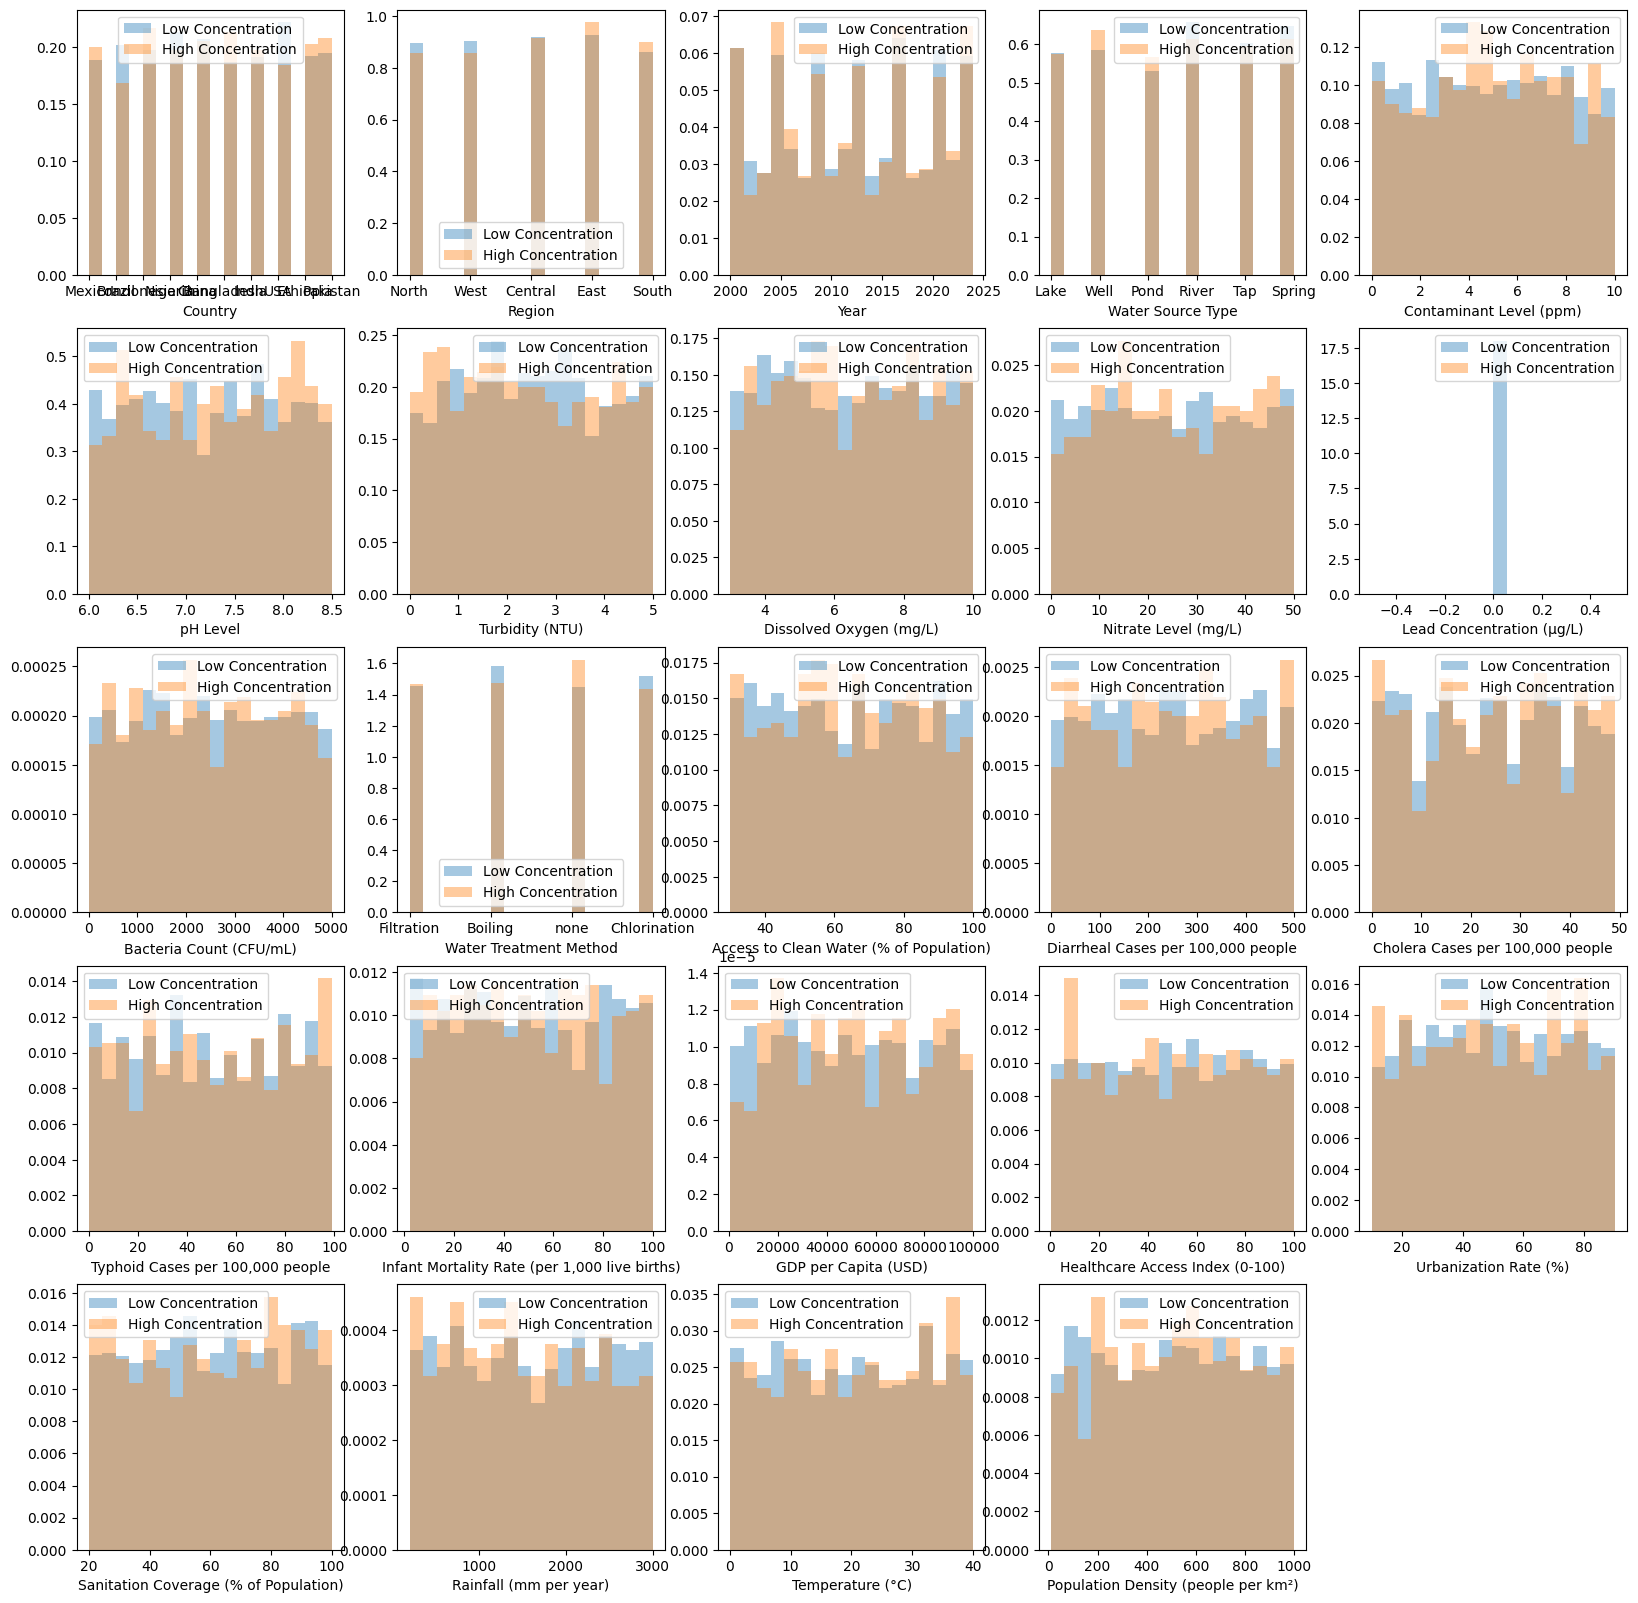

In [17]:
selection_dict={"Low Concentration":data["Lead Concentration (µg/L)"]==0.,"High Concentration":data["Lead Concentration (µg/L)"]!=0}

plt.figure(figsize=(20,20))

for i,column_name in enumerate(data.columns):
    plt.subplot(5,5,i+1)
    compare_distributions(data,column_name,
                     selection_dict,
                     alpha=0.4,
                     density=1,
                     bins=18,
                     stacked=True
                     )
    plt.xlabel(column_name)
plt.show()

There is not much to be interpreted from the above plot besides that distributions for features are relatively similar across low and high concentrations. Since we do not see any distinct differences, we can plot correlation matrices to see the similarities between features and choose features that are not highly correlated (as to not overemphasize some relationships over others which can alter findings)

In [18]:
# do next, correlation matrices

corr_matrix = data.select_dtypes('number').corr()

corr_matrix

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
Year,1.000000,-0.012009,0.002086,0.002336,-0.004248,0.002293,0.006096,-0.021711,0.004679,-0.009354,-0.030197,0.033197,-0.011524,0.033907,0.003756,0.004420,-0.006379,0.015574,0.007986,0.000411
Contaminant Level (ppm),-0.012009,1.000000,0.015832,0.012436,0.006122,-0.048365,0.010688,0.020452,0.005867,-0.002599,0.027019,0.020529,-0.028094,-0.015153,-0.045862,0.002442,0.012094,-0.005317,0.024128,-0.005532
pH Level,0.002086,0.015832,1.000000,-0.044292,0.007651,-0.000528,0.028418,0.022078,0.015276,0.018386,0.024828,0.011574,0.004177,-0.002972,0.015509,0.017085,-0.047860,-0.001774,-0.007290,-0.001965
Turbidity (NTU),0.002336,0.012436,-0.044292,1.000000,-0.000677,0.021619,-0.016858,0.002440,0.028929,0.016556,0.021453,-0.002389,0.006440,-0.015601,0.001364,-0.004110,0.030491,0.006596,0.007078,0.006886
Dissolved Oxygen (mg/L),-0.004248,0.006122,0.007651,-0.000677,1.000000,-0.033023,0.007684,0.005714,0.022059,-0.003231,-0.017889,0.041853,-0.018998,-0.015512,-0.001830,-0.001918,0.019067,-0.007434,0.008028,-0.010568
Nitrate Level (mg/L),0.002293,-0.048365,-0.000528,0.021619,-0.033023,1.000000,0.020263,-0.004577,0.023942,-0.010578,0.007948,-0.007345,0.037444,0.012970,0.029534,0.004033,-0.006235,0.016400,0.013920,-0.011292
Lead Concentration (µg/L),0.006096,0.010688,0.028418,-0.016858,0.007684,0.020263,1.000000,-0.005769,-0.000315,0.014498,0.017190,0.013337,0.002443,0.026144,-0.008526,0.003227,0.005305,-0.044359,0.018132,0.019483
Bacteria Count (CFU/mL),-0.021711,0.020452,0.022078,0.002440,0.005714,-0.004577,-0.005769,1.000000,-0.011875,0.015419,-0.010092,-0.011258,-0.020969,-0.012221,-0.017679,0.012910,-0.020361,-0.039331,-0.046582,0.009718
Access to Clean Water (% of Population),0.004679,0.005867,0.015276,0.028929,0.022059,0.023942,-0.000315,-0.011875,1.000000,0.009076,0.022508,-0.015023,0.027276,0.016690,-0.016930,-0.017113,0.012890,-0.024775,-0.000029,0.008631
"Diarrheal Cases per 100,000 people",-0.009354,-0.002599,0.018386,0.016556,-0.003231,-0.010578,0.014498,0.015419,0.009076,1.000000,0.014747,-0.012675,0.031683,0.002447,-0.000706,0.015574,0.033032,-0.023887,-0.007984,0.006277


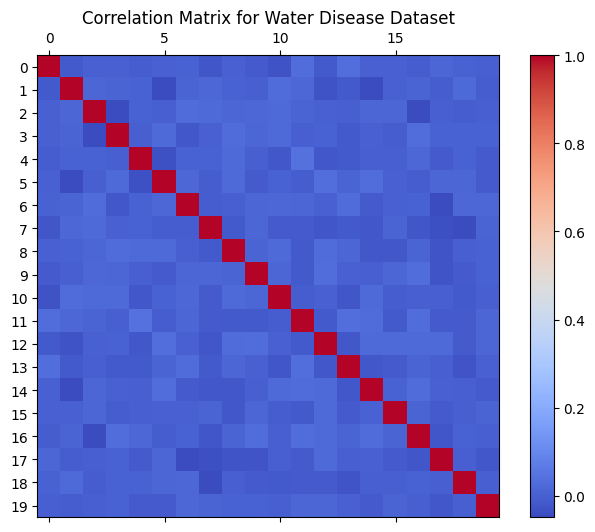

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)

ax.set_yticks(np.arange(len(corr_matrix.columns)))

plt.title("Correlation Matrix for Water Disease Dataset")
plt.show()

In [20]:
# That was not what I was expecting. I thought a lot of the values would be correlated with each other, but it seems like they are not correlated at all
# Since they are not highly correlated, I might need to use all features for machine learning task

In [21]:
cov_matrix = np.cov(corr_matrix, rowvar=False) 
#print(cov_matrix)

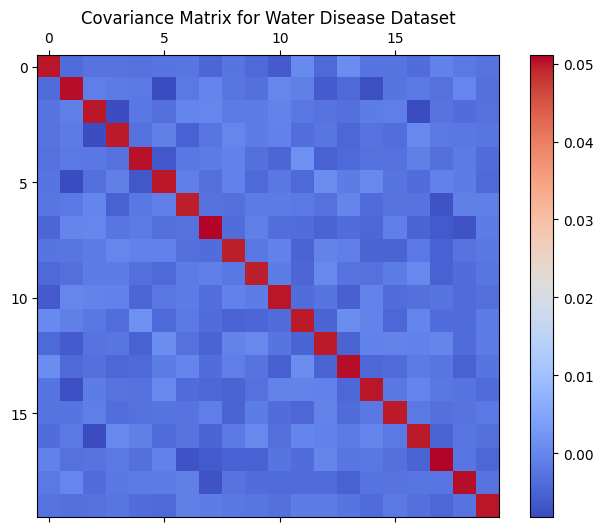

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cov_matrix, cmap='coolwarm')
fig.colorbar(cax)

plt.title("Covariance Matrix for Water Disease Dataset")
plt.show()

In [23]:
# Once again, not much to interpret. Since this data is complex with many features, I believe a MLP neural network would work fine
# I would also like to try a Support Vector Classifier and possibly random forest

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

Data are suggested to be normalized or rescaled in preparation for a neural network model

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

In [25]:
# Min-Max Normalization [0, 1] for numerical data
min_max_scaler = MinMaxScaler()
normalized_data = min_max_scaler.fit_transform(data.select_dtypes('number'))

# Standardization (Mean=0, Std=1) for numerical data
standard_scaler = StandardScaler()
standardized_data = standard_scaler.fit_transform(data.select_dtypes('number'))

In [26]:
data

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,0,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,0,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,0,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,0,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,0,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,1,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,1,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,0,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,1,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


In [27]:
normalized_data

normalized_df = pd.DataFrame(normalized_data, columns = ['Year',
       'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)', 'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)'])
normalized_df

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,0.625000,0.606,0.448,0.787575,0.182857,0.164798,0.0,0.669068,0.051300,0.945892,0.673469,0.444444,0.756663,0.568618,0.969336,0.932833,0.540385,0.928903,0.122214,0.589484
1,0.708333,0.524,0.736,0.959920,0.122857,0.314177,0.0,0.424570,0.850672,0.244489,0.551020,0.080808,0.768304,0.167952,0.847179,0.792245,0.113903,0.490175,0.422489,0.226491
2,0.916667,0.024,0.172,0.158317,0.060000,0.733280,0.0,0.466186,0.075450,0.549098,0.795918,0.505051,0.473706,0.859937,0.583024,0.785866,0.919605,0.669525,0.542700,0.047523
3,0.666667,0.791,0.284,0.392786,0.017143,0.738286,0.0,0.756102,0.393255,0.006012,0.673469,0.131313,0.955785,0.308216,0.389618,0.763477,0.928232,0.263308,0.093413,0.551062
4,0.208333,0.012,0.864,0.845691,0.878571,0.987185,0.0,0.836735,0.094170,0.933868,0.632653,0.686869,0.579189,0.252849,0.228881,0.569356,0.615404,0.748482,0.785875,0.408493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.083333,0.282,0.560,0.887776,0.955714,0.751502,1.0,0.071829,0.090454,0.024048,0.571429,0.565657,0.732258,0.208535,0.753081,0.064916,0.413228,0.022865,0.790884,0.881699
2996,0.791667,0.813,0.932,0.955912,0.660000,0.760913,1.0,0.762305,0.738925,0.098196,0.693878,0.343434,0.705095,0.790801,0.067341,0.160851,0.730683,0.892819,0.830203,0.057634
2997,0.375000,0.118,0.304,0.951904,0.581429,0.722467,0.0,0.288115,0.715919,0.494990,1.000000,0.090909,0.965690,0.483249,0.861609,0.948843,0.342211,0.304394,0.288254,0.640040
2998,0.375000,0.756,0.048,0.699399,0.847143,0.505607,1.0,0.584034,0.689483,0.464930,0.673469,0.909091,0.190442,0.488580,0.203527,0.134459,0.041635,0.060379,0.366391,0.640040


In [28]:
standardized_data

standardized_df = pd.DataFrame(standardized_data, columns = ['Year',
       'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)'])
standardized_df

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,0.413295,0.386632,-0.188586,1.021292,-1.091349,-1.158418,-0.580943,0.597773,-1.527319,1.542280,0.610529,-0.181854,0.890639,0.245534,1.622976,1.516884,0.123468,1.478103,-1.299780,0.309326
1,0.689994,0.099878,0.810937,1.627034,-1.298488,-0.644033,-0.580943,-0.256066,1.227657,-0.886799,0.191833,-1.424118,0.930694,-1.147661,1.201058,1.023367,-1.349596,-0.024284,-0.273880,-0.958204
2,1.381740,-1.648621,-1.146462,-1.190369,-1.515490,0.799141,-0.580943,-0.110732,-1.444089,0.168115,1.029225,0.025190,-0.082988,1.258510,0.288691,1.000974,1.433290,0.589884,0.136822,-1.583143
3,0.551645,1.033576,-0.757759,-0.366279,-1.663446,0.816380,-0.580943,0.901717,-0.348796,-1.712686,0.610529,-1.251582,1.575797,-0.659936,-0.379318,0.922381,1.463088,-0.801170,-1.398178,0.175158
4,-0.970197,-1.690585,1.255170,1.225554,1.310472,1.673458,-0.580943,1.183303,-1.379573,1.500639,0.470963,0.646323,0.279970,-0.852459,-0.934491,0.240941,0.382582,0.860264,0.967639,-0.322674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-1.385245,-0.746396,0.200118,1.373467,1.576793,0.861888,1.721340,-1.487914,-1.392378,-1.650224,0.261615,0.232234,0.806663,-1.006547,0.876053,-1.529834,-0.315731,-1.624546,0.984752,1.329705
2996,0.966693,1.110510,1.491168,1.612947,0.555896,0.894296,1.721340,0.923378,0.842531,-1.393435,0.680311,-0.526927,0.713201,1.018109,-1.492434,-1.193066,0.780754,1.354535,1.119086,-1.547835
2997,-0.416800,-1.319904,-0.688348,1.598860,0.284643,0.761907,-0.580943,-0.732595,0.763241,-0.019271,1.727052,-1.389611,1.609879,-0.051311,1.250899,1.573085,-0.561026,-0.660474,-0.732498,0.485862
2998,-0.416800,0.911181,-1.576813,0.711378,1.201971,0.015152,1.721340,0.300816,0.672131,-0.123374,0.610529,1.405484,-1.057670,-0.032776,-1.022059,-1.285711,-1.599210,-1.496085,-0.465541,0.485862


I will try both normalized data and standardized data to see which one fits the task better

/home/friday/data3402/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7141: RuntimeWarning: invalid value encountered in divide
  tops = (tops / np.diff(bins)) / tops[-1].sum()


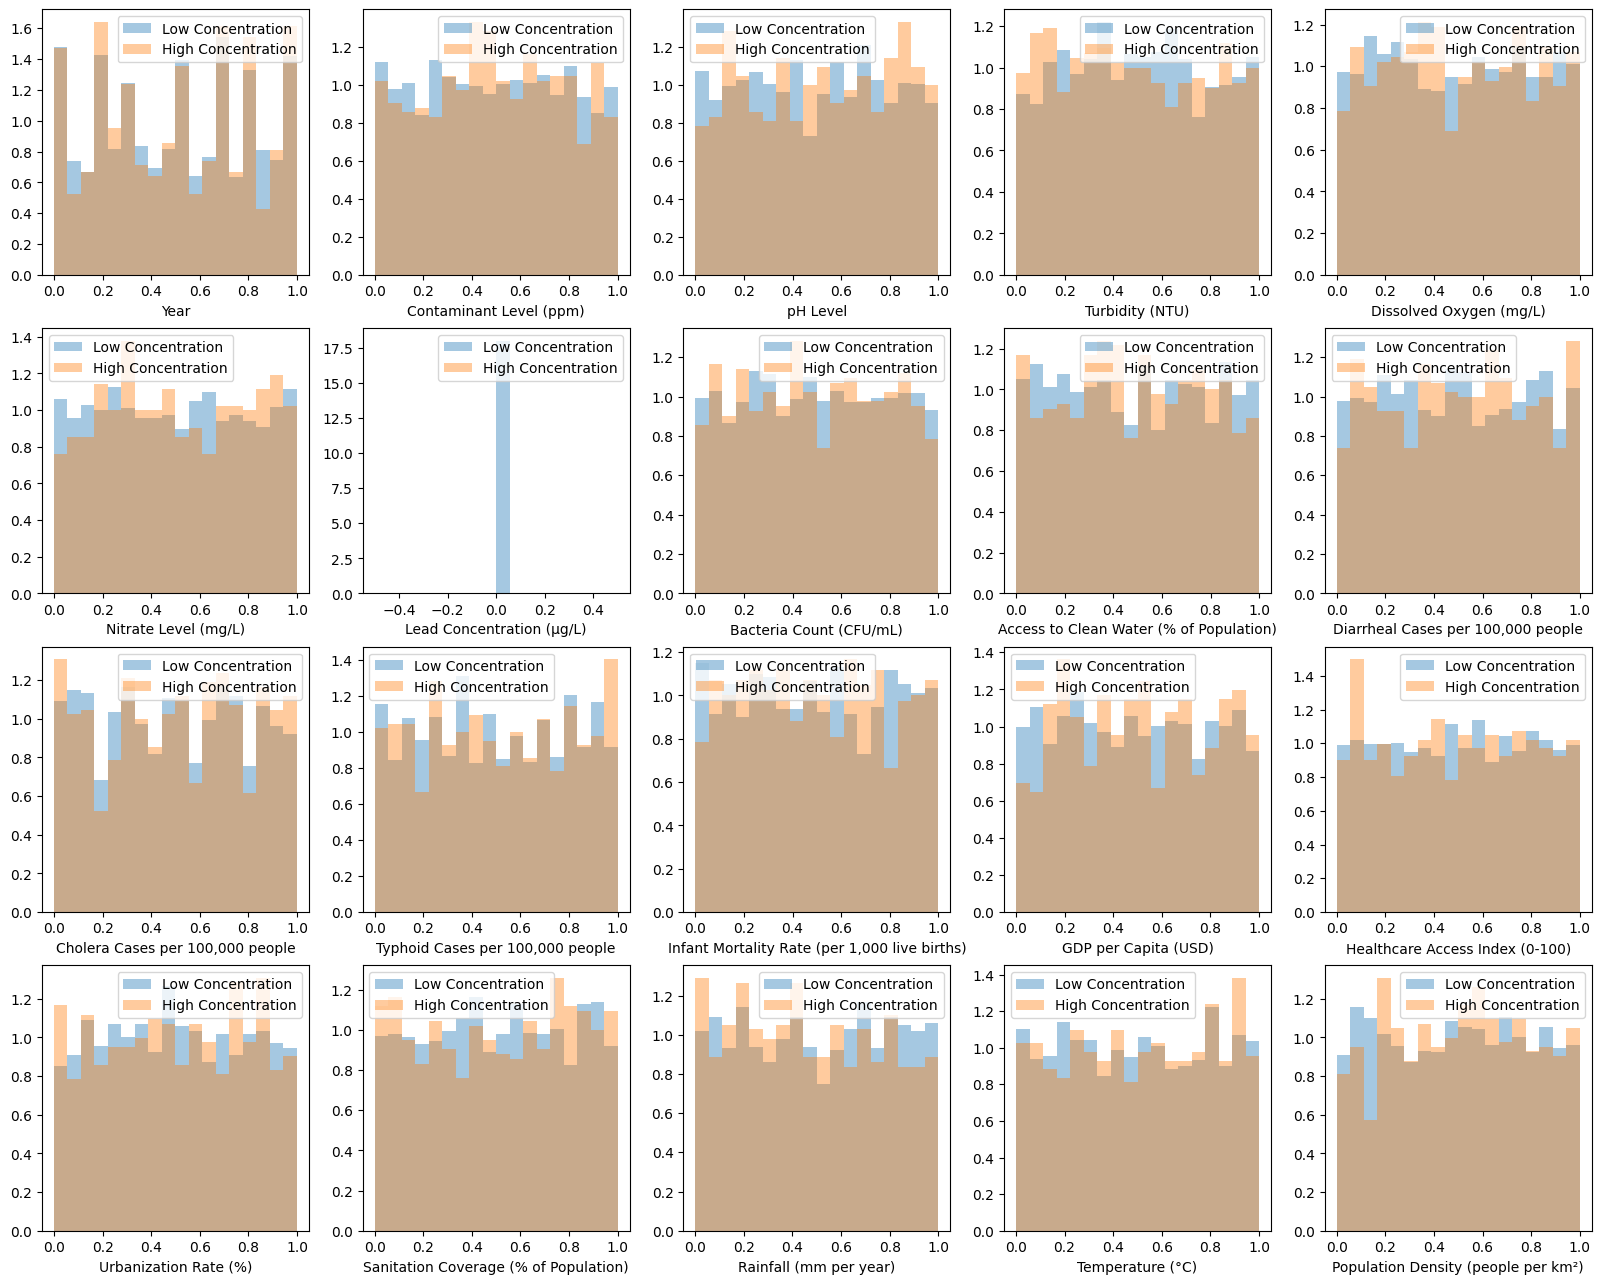

In [29]:
selection_dict={"Low Concentration":normalized_df["Lead Concentration (µg/L)"]==0.,"High Concentration":normalized_df["Lead Concentration (µg/L)"]!=0}

plt.figure(figsize=(20,20))

for i,column_name in enumerate(normalized_df.columns):
    plt.subplot(5,5,i+1)
    compare_distributions(normalized_df,column_name,
                     selection_dict,
                     alpha=0.4,
                     density=1,
                     bins=18,
                     stacked=True
                     )
    plt.xlabel(column_name)
plt.show()

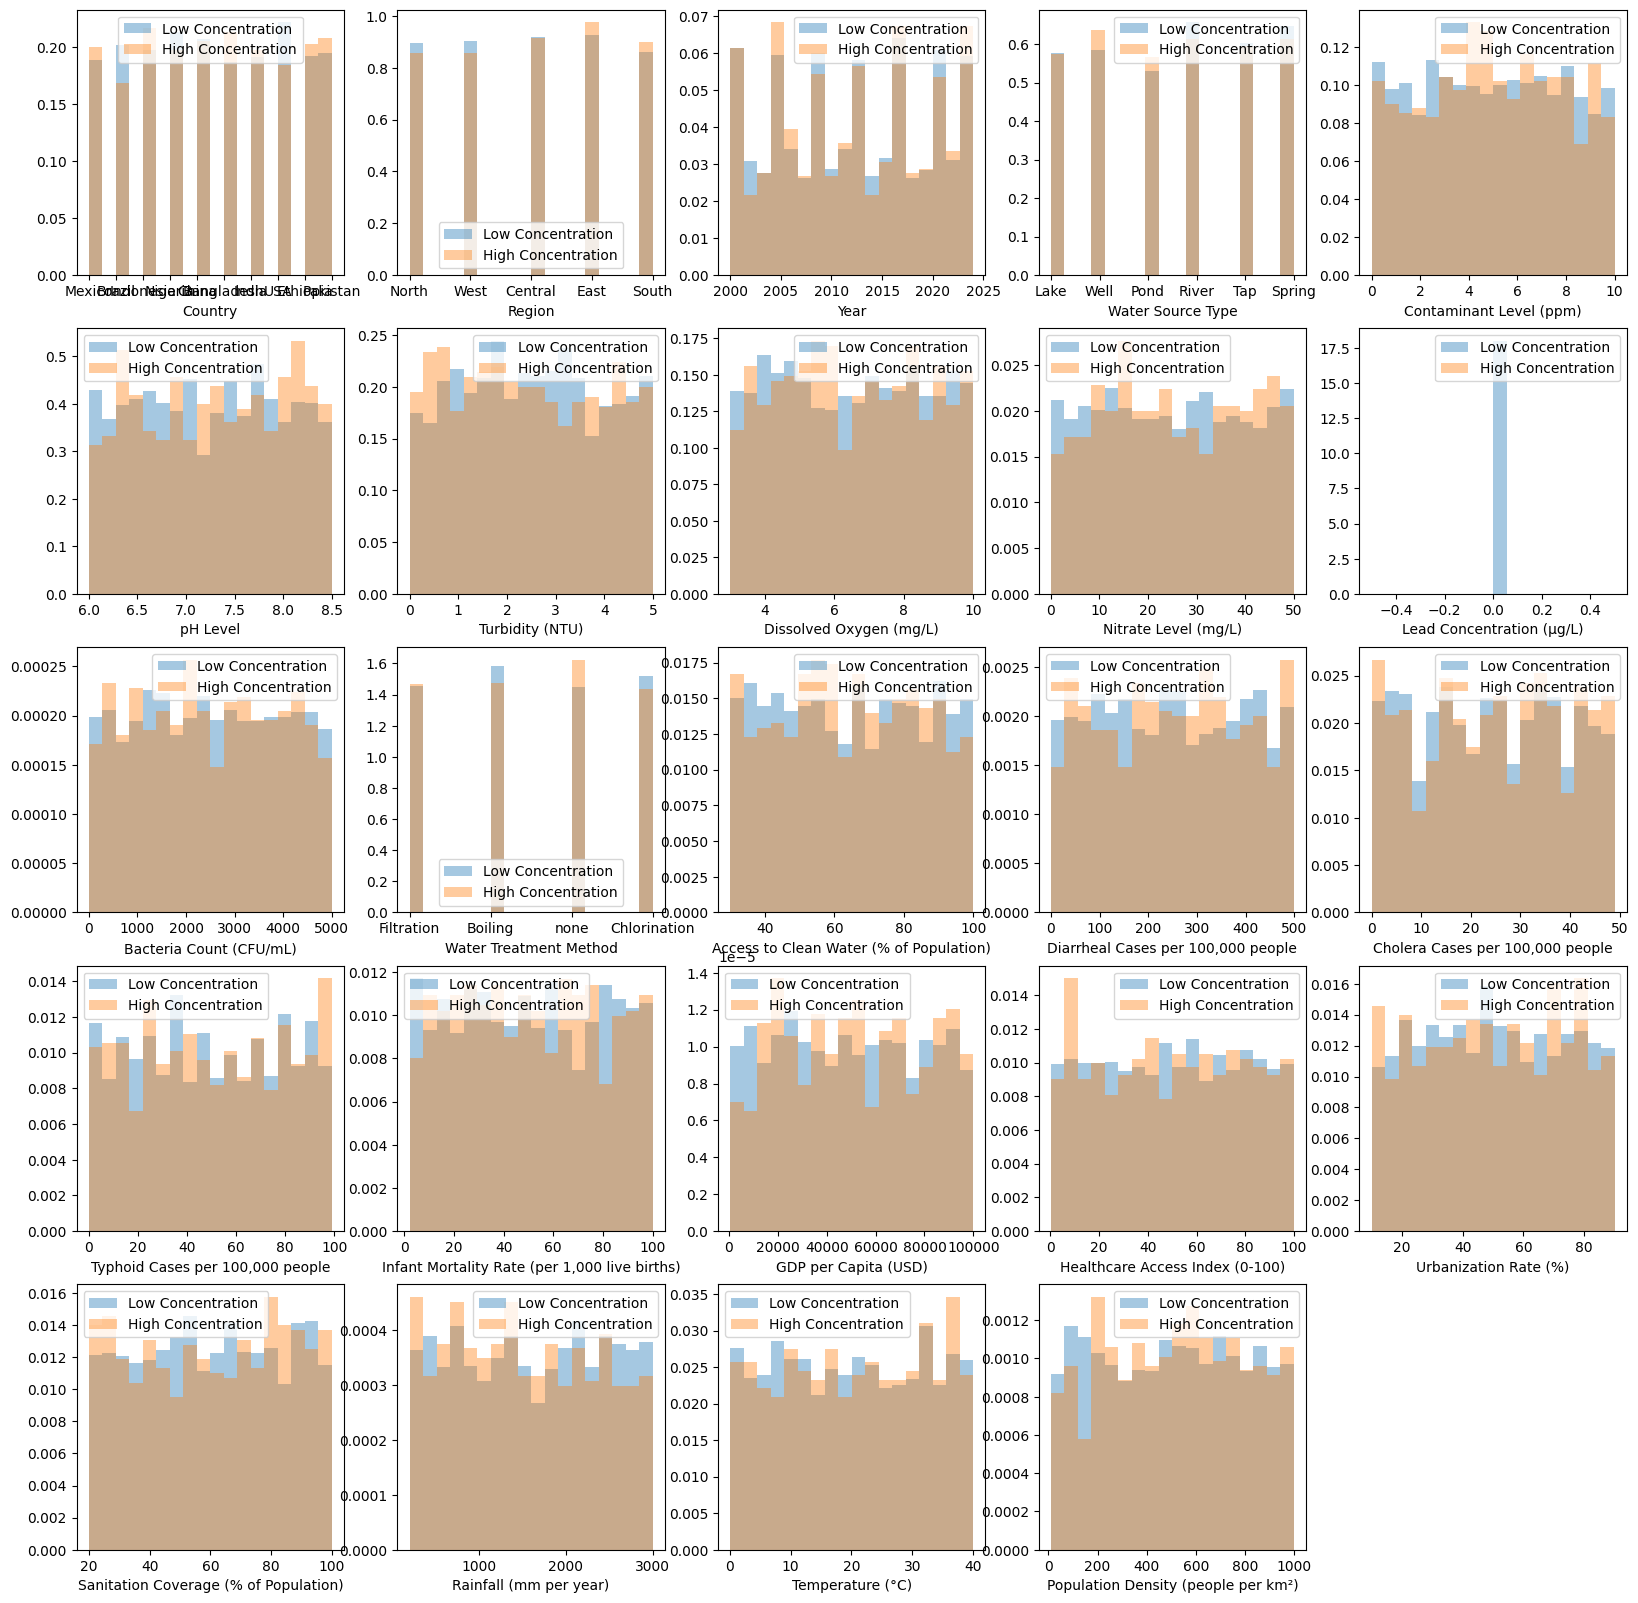

In [30]:
selection_dict={"Low Concentration":data["Lead Concentration (µg/L)"]==0.,"High Concentration":data["Lead Concentration (µg/L)"]!=0}

plt.figure(figsize=(20,20))

for i,column_name in enumerate(data.columns):
    plt.subplot(5,5,i+1)
    compare_distributions(data,column_name,
                     selection_dict,
                     alpha=0.4,
                     density=1,
                     bins=18,
                     stacked=True
                     )
    plt.xlabel(column_name)
plt.show()

In [31]:
# There is no observed differences between the original data and the normalized data distributions, which makes sense.

In [32]:
# We will now one-hot encode categorical variables

In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

# Reshape is required if encoding a single column/Series
encoded_data = encoder.fit_transform(data[['Country', 'Region', 'Water Source Type', 'Water Treatment Method']])

# Convert back to a DataFrame with clear column names
df_ohe = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Country', 'Region', 'Water Source Type', 'Water Treatment Method']))

In [34]:
df_ohe

,Country_Bangladesh,Country_Brazil,Country_China,Country_Ethiopia,Country_India,Country_Indonesia,Country_Mexico,Country_Nigeria,Country_Pakistan,Country_USA,...,Water Source Type_Lake,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Boiling,Water Treatment Method_Chlorination,Water Treatment Method_Filtration,Water Treatment Method_none
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [35]:
ml_prepared_df = pd.concat([normalized_df, df_ohe], axis=1)

In [36]:
ml_prepared_df

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people",...,Water Source Type_Lake,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Boiling,Water Treatment Method_Chlorination,Water Treatment Method_Filtration,Water Treatment Method_none
0,0.625000,0.606,0.448,0.787575,0.182857,0.164798,0.0,0.669068,0.051300,0.945892,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.708333,0.524,0.736,0.959920,0.122857,0.314177,0.0,0.424570,0.850672,0.244489,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.916667,0.024,0.172,0.158317,0.060000,0.733280,0.0,0.466186,0.075450,0.549098,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.666667,0.791,0.284,0.392786,0.017143,0.738286,0.0,0.756102,0.393255,0.006012,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.208333,0.012,0.864,0.845691,0.878571,0.987185,0.0,0.836735,0.094170,0.933868,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.083333,0.282,0.560,0.887776,0.955714,0.751502,1.0,0.071829,0.090454,0.024048,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2996,0.791667,0.813,0.932,0.955912,0.660000,0.760913,1.0,0.762305,0.738925,0.098196,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2997,0.375000,0.118,0.304,0.951904,0.581429,0.722467,0.0,0.288115,0.715919,0.494990,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2998,0.375000,0.756,0.048,0.699399,0.847143,0.505607,1.0,0.584034,0.689483,0.464930,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [ ]:
# Problem Formulation --> Getting Ready for Machine Learning Task

In [37]:
ml_prepared_df.columns

Index(['Year', 'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)',
       'Country_Bangladesh', 'Country_Brazil', 'Country_China',
       'Country_Ethiopia', 'Country_India', 'Country_Indonesia',
       'Country_Mexico', 'Country_Nigeria', 'Country_Pakistan', 'Country_USA',
       'Region_Central', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Water Source Type_Lake', 'Water Source Typ

In [49]:
ml_prepared_df_numerical = ml_prepared_df.iloc[:, :20]

In [50]:
ml_prepared_df_numerical

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,0.625000,0.606,0.448,0.787575,0.182857,0.164798,0.0,0.669068,0.051300,0.945892,0.673469,0.444444,0.756663,0.568618,0.969336,0.932833,0.540385,0.928903,0.122214,0.589484
1,0.708333,0.524,0.736,0.959920,0.122857,0.314177,0.0,0.424570,0.850672,0.244489,0.551020,0.080808,0.768304,0.167952,0.847179,0.792245,0.113903,0.490175,0.422489,0.226491
2,0.916667,0.024,0.172,0.158317,0.060000,0.733280,0.0,0.466186,0.075450,0.549098,0.795918,0.505051,0.473706,0.859937,0.583024,0.785866,0.919605,0.669525,0.542700,0.047523
3,0.666667,0.791,0.284,0.392786,0.017143,0.738286,0.0,0.756102,0.393255,0.006012,0.673469,0.131313,0.955785,0.308216,0.389618,0.763477,0.928232,0.263308,0.093413,0.551062
4,0.208333,0.012,0.864,0.845691,0.878571,0.987185,0.0,0.836735,0.094170,0.933868,0.632653,0.686869,0.579189,0.252849,0.228881,0.569356,0.615404,0.748482,0.785875,0.408493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.083333,0.282,0.560,0.887776,0.955714,0.751502,1.0,0.071829,0.090454,0.024048,0.571429,0.565657,0.732258,0.208535,0.753081,0.064916,0.413228,0.022865,0.790884,0.881699
2996,0.791667,0.813,0.932,0.955912,0.660000,0.760913,1.0,0.762305,0.738925,0.098196,0.693878,0.343434,0.705095,0.790801,0.067341,0.160851,0.730683,0.892819,0.830203,0.057634
2997,0.375000,0.118,0.304,0.951904,0.581429,0.722467,0.0,0.288115,0.715919,0.494990,1.000000,0.090909,0.965690,0.483249,0.861609,0.948843,0.342211,0.304394,0.288254,0.640040
2998,0.375000,0.756,0.048,0.699399,0.847143,0.505607,1.0,0.584034,0.689483,0.464930,0.673469,0.909091,0.190442,0.488580,0.203527,0.134459,0.041635,0.060379,0.366391,0.640040


In [57]:
from sklearn.utils import shuffle 
from sklearn.neural_network import MLPClassifier 
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score 

In [69]:
from sklearn.utils import shuffle 
from sklearn.neural_network import MLPClassifier 
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score 

kf = KFold(n_splits=5, shuffle=True) # 5 folds

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold{i}:")
    print(f" Train:index={train_index}")
    print(f"Test:index{test_index}")



X = ml_prepared_df_numerical.drop(columns=['Lead Concentration (µg/L)']) # Remove target from input features
y = ml_prepared_df_numerical['Lead Concentration (µg/L)']                # Target variable


nn_all=[] #this will store the accuracy of each addition 
nn_f1_all=[] 


for repeat in range(5):    
    print('repeat is', repeat) 

    test_score_all_nn=[] 
    test_score_all_nn_f1=[] 

    #split data into train, valid, and test 

    for i, (train_index, test_index) in enumerate(kf.split(X)): 
        print('batch is', i) 

        train_index_shuffle=shuffle(train_index) #create more randomness in data 
        sub_train_index=train_index_shuffle[:int(len(train_index)*0.875)] #this is 70 percent 
        sub_validation_index=train_index_shuffle[int(len(train_index)*0.875):] #this is 10 percent

        train_feature = X.iloc[sub_train_index]
        train_label = y.iloc[sub_train_index]
        
        valid_feature = X.iloc[sub_validation_index]
        valid_label = y.iloc[sub_validation_index]
        
        test_feature = X.iloc[test_index]
        test_label = y.iloc[test_index]

        #we have splitted the data into the three sets 

        network_structure= [(64,32),(128, 64),(32, 16),(128,64,32)] 
        learning_rate = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5] 

        best_valid_score=float('-inf')

        for structure in network_structure: 
            for rate in learning_rate: 

                model=MLPClassifier(hidden_layer_sizes=structure, learning_rate='constant', learning_rate_init=rate, batch_size=64, 
                                    max_iter=1000, random_state=1) #create the neural network classifier 

                model.fit(train_feature, train_label) 
                valid_score=model.score(valid_feature, valid_label) 

                if valid_score>best_valid_score: 
                    best_valid_score = valid_score 
                    test_score = model.score(test_feature, test_label) #validation set is required to have a better model than just including train-test 
                    pred=model.predict(test_feature) 
                    best_s=structure #store best structure 
                    best_r=rate #store best rate 
        
        print('Test score is', test_score) 
        test_score_all_nn.append(test_score) 
        test_score_all_nn_f1.append(f1_score(test_label, pred, average='weighted')) 

        print('F1 score is', f1_score(test_label, pred, average='weighted')) 
        print('best s is', best_s) 
        print('best r is', best_r) 
        print('') 

    print('mean accuracy in this repeat', np.mean(test_score_all_nn)) 
    print('mean F1 score in this repeat', np.mean(test_score_all_nn_f1)) 

    nn_all.append(np.mean(test_score_all_nn)) 


print('mean accuracy for all repeats', np.mean(nn_all)) 

Fold0:
 Train:index=[   0    1    2 ... 2997 2998 2999]
Test:index[  10   13   23   28   30   33   41   46   61   70   79   84   85   87
   93  102  112  116  120  127  144  147  151  155  159  160  162  169
  171  175  181  187  195  197  199  209  210  213  214  221  222  228
  231  232  233  235  244  253  258  265  269  274  281  296  300  318
  320  325  330  332  333  336  342  346  347  352  354  358  360  361
  362  367  370  373  376  379  380  382  384  387  390  391  411  412
  421  423  428  435  439  449  454  456  458  471  477  496  503  504
  509  518  523  525  527  531  533  534  538  539  567  572  587  588
  595  597  605  613  616  620  621  625  627  633  640  641  656  659
  668  672  674  685  686  693  695  696  699  700  704  705  706  716
  720  724  747  755  756  757  765  779  782  784  795  803  805  810
  812  821  828  829  830  832  835  844  846  848  861  873  874  877
  878  881  883  889  891  899  912  915  932  942  943  944  946  952
  953  955 

In [ ]:
# mean accuracy for all repeats (5 repeats each with 5 randomized batches) = 0.7476667